# Alzheimer's Disease vs Healthy Control Classification from Eyes-Closed Resting-State EEG

**Research pipeline — NOT a clinical diagnostic tool.**

This notebook builds a subject-level, leakage-free machine learning / deep learning pipeline that
classifies subjects as Alzheimer's Disease (AD) or Healthy Control (HC) using 19-channel eyes-closed
resting-state EEG recordings stored as per-channel `.txt` files.

**Pipeline overview**

```
Subjects -> Stratified subject-level split -> Load EEG -> Preprocess -> Epoch ->
Train/Validate/Test (baseline ML + deep learning) -> Subject-level aggregation ->
Metrics + Confidence Intervals -> Cross-validation -> Interpretability -> Save outputs
```

**Design priorities (in order):**
1. No data leakage (subject-level splits everywhere).
2. Subject-level evaluation is the primary result (epoch-level is secondary/diagnostic).
3. Correct, robust EEG loading from the 19 `.txt` files per subject.
4. Reproducibility (fixed seeds, frozen decision thresholds).
5. Generalization over artificially inflated accuracy.

> **Disclaimer:** This notebook implements a *research* classification pipeline for a small EEG
> dataset. It is **not validated for clinical use** and must never be used to diagnose, screen, or
> make treatment decisions for real patients.


## 0. Installation

Run the cell below once to install all required dependencies. If you already have these packages
installed (e.g., in a conda environment), you can skip this cell.

Required packages: `numpy`, `scipy`, `pandas`, `scikit-learn`, `tensorflow`, `matplotlib`, `seaborn`, `tqdm`.


In [ ]:
# Uncomment the line below to install dependencies in this environment.
# %pip install -q numpy scipy pandas scikit-learn tensorflow matplotlib seaborn tqdm
print("If dependencies are missing, uncomment and run the %pip install line above, then restart the kernel.")


Note: you may need to restart the kernel to use updated packages.
If dependencies are missing, uncomment and run the %pip install line above, then restart the kernel.


## 1. Imports, Configuration, and Reproducibility

All global configuration lives here. Change `ROOT` if your dataset lives somewhere else.


In [2]:
import os
import json
import random
import warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, sosfiltfilt, welch
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, brier_score_loss, confusion_matrix, roc_curve,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

warnings.filterwarnings("ignore")

# --------------------------- REPRODUCIBILITY ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --------------------------- DATASET CONFIG ---------------------------
FS = 128                     # sampling frequency (Hz)
EPOCH_SEC = 8                # epoch length in seconds
EPOCH_SAMPLES = FS * EPOCH_SEC  # 1024 samples per epoch
BAND = (0.5, 45)             # overall band-pass filter range (Hz)

ROOT = Path("FINAL_DATASET")
ALZ_FOLDER = ROOT / "Alzehiemers" / "eyes-closed"
HEALTHY_FOLDER = ROOT / "Healthy" / "eyes-closed"

CHANNELS = [
    "Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz",
    "C3", "C4", "Cz",
    "P3", "P4", "Pz",
    "T3", "T4", "T5", "T6",
    "O1", "O2"
]
N_CHANNELS = len(CHANNELS)

BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

LABEL_MAP = {"Healthy": 0, "Alzheimer": 1}

# --------------------------- ARTIFACT REJECTION CONFIG ---------------------------
ARTIFACT_REJECTION_ENABLED = True
ARTIFACT_STD_THRESHOLD = 6.0   # epoch flagged bad if peak |amplitude| > THRESH * subject signal std
ARTIFACT_ABS_THRESHOLD = None  # optional hard absolute cutoff in raw signal units; None disables it

# --------------------------- SPLIT CONFIG ---------------------------
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# --------------------------- CROSS-VALIDATION CONFIG ---------------------------
RUN_CV = True          # runs 5-fold subject-level CV for baseline models
RUN_DL_CV = False      # deep-learning CV is expensive; set True only if you have time/GPU
CV_FOLDS = 5

# --------------------------- OUTPUT DIRECTORIES ---------------------------
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")
MODELS_DIR = Path("models")
for d in (RESULTS_DIR, PLOTS_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print(f"FS={FS} Hz | EPOCH_SAMPLES={EPOCH_SAMPLES} | N_CHANNELS={N_CHANNELS}")
print(f"TensorFlow version: {tf.__version__}")


FS=128 Hz | EPOCH_SAMPLES=1024 | N_CHANNELS=19
TensorFlow version: 2.21.0


## 2. EEG Data Loader

Each subject folder contains 19 `.txt` files (one per channel). The loader below:

- Discovers patient folders automatically (no hard-coded names).
- Loads channels in the exact order defined by `CHANNELS`.
- Supports whitespace- **or** comma-separated numeric values.
- Casts data to `float32`.
- Verifies all 19 channel files exist.
- Detects and safely handles `NaN`/`Inf` values (linear interpolation, with edge fallback to 0).
- Checks channel lengths and trims all channels to the shortest common length if they differ.
- Returns an array of shape `(19, total_samples)`.


In [3]:
def discover_subject_folders(class_folder: Path):
    """Automatically discover patient subfolders inside a class folder."""
    if not class_folder.exists():
        raise FileNotFoundError(f"Class folder not found: {class_folder}")
    subject_dirs = sorted([p for p in class_folder.iterdir() if p.is_dir()],
                           key=lambda p: p.name)
    return subject_dirs


def _parse_channel_file(fpath: Path) -> np.ndarray:
    """Parse a single-channel EEG text file. Supports whitespace or comma delimiters."""
    raw_text = fpath.read_text().strip()
    if raw_text == "":
        raise ValueError(f"Empty channel file: {fpath}")
    raw_text = raw_text.replace(",", " ").replace(";", " ").replace("\t", " ")
    values = np.fromstring(raw_text, sep=" ", dtype=np.float64)
    if values.size == 0:
        raise ValueError(f"Could not parse any numeric values from: {fpath}")
    return values.astype(np.float32)


def _fix_nan_inf(x: np.ndarray, source_name: str = "") -> np.ndarray:
    """Replace NaN/Inf values via linear interpolation; report how many were fixed."""
    bad_mask = ~np.isfinite(x)
    n_bad = int(bad_mask.sum())
    if n_bad == 0:
        return x
    good_idx = np.flatnonzero(~bad_mask)
    if good_idx.size == 0:
        warnings.warn(f"{source_name}: all values non-finite, replacing with zeros.")
        return np.zeros_like(x)
    bad_idx = np.flatnonzero(bad_mask)
    x = x.copy()
    x[bad_idx] = np.interp(bad_idx, good_idx, x[good_idx])
    print(f"  [warn] {source_name}: fixed {n_bad} NaN/Inf sample(s) via interpolation.")
    return x


def load_subject_data(subject_dir: Path, channels=CHANNELS, verbose: bool = False) -> np.ndarray:
    """
    Load all 19 channel files for one subject.

    Returns
    -------
    np.ndarray of shape (n_channels, total_samples), dtype float32
    """
    channel_arrays = []
    lengths = []
    missing = []

    for ch in channels:
        fpath = subject_dir / f"{ch}.txt"
        if not fpath.exists():
            missing.append(ch)
            continue
        arr = _parse_channel_file(fpath)
        arr = _fix_nan_inf(arr, source_name=f"{subject_dir.name}/{ch}")
        channel_arrays.append(arr)
        lengths.append(len(arr))

    if missing:
        raise FileNotFoundError(
            f"Subject '{subject_dir.name}' is missing channel file(s): {missing}"
        )

    min_len = min(lengths)
    max_len = max(lengths)
    if min_len != max_len:
        if verbose:
            print(f"  [warn] {subject_dir.name}: channel length mismatch "
                  f"(min={min_len}, max={max_len}). Trimming all channels to {min_len}.")
    channel_arrays = [a[:min_len] for a in channel_arrays]

    data = np.vstack(channel_arrays).astype(np.float32)  # (n_channels, total_samples)
    assert data.shape[0] == len(channels), "Channel count mismatch after loading."
    return data


def build_subject_index(alz_folder: Path, healthy_folder: Path):
    """Return a DataFrame with one row per subject: id, path, label, class name."""
    records = []
    for cls_name, cls_folder, label in [("Alzheimer", alz_folder, 1), ("Healthy", healthy_folder, 0)]:
        for subj_dir in discover_subject_folders(cls_folder):
            records.append({
                "subject_id": f"{cls_name}_{subj_dir.name}",
                "path": str(subj_dir),
                "class_name": cls_name,
                "label": label,
            })
    df = pd.DataFrame.from_records(records)
    if df.empty:
        raise RuntimeError("No subjects discovered. Check ROOT / ALZ_FOLDER / HEALTHY_FOLDER paths.")
    return df


subject_index = build_subject_index(ALZ_FOLDER, HEALTHY_FOLDER)
print(f"Discovered {len(subject_index)} subjects "
      f"({(subject_index.label == 1).sum()} Alzheimer, {(subject_index.label == 0).sum()} Healthy)")
subject_index.head()


Discovered 232 subjects (116 Alzheimer, 116 Healthy)


,subject_id,path,class_name,label
0,Alzheimer_patient1,FINAL_DATASET/Alzehiemers/eyes-closed/patient1,Alzheimer,1
1,Alzheimer_patient10,FINAL_DATASET/Alzehiemers/eyes-closed/patient10,Alzheimer,1
2,Alzheimer_patient100,FINAL_DATASET/Alzehiemers/eyes-closed/patient100,Alzheimer,1
3,Alzheimer_patient101,FINAL_DATASET/Alzehiemers/eyes-closed/patient101,Alzheimer,1
4,Alzheimer_patient102,FINAL_DATASET/Alzehiemers/eyes-closed/patient102,Alzheimer,1


## 3. Stratified Subject-Level Train / Validation / Test Split

**This is the most important step for preventing data leakage.** We split *subjects*, never epochs.
Every epoch belonging to a subject stays entirely within one split (train, validation, or test).


In [4]:
subject_ids = subject_index["subject_id"].values
subject_labels = subject_index["label"].values

train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    subject_ids, subject_labels,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=subject_labels,
    random_state=SEED,
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels,
    test_size=relative_test_size,
    stratify=temp_labels,
    random_state=SEED,
)

train_ids, val_ids, test_ids = set(train_ids), set(val_ids), set(test_ids)

# --------------------------- LEAKAGE VERIFICATION ---------------------------
assert train_ids.isdisjoint(val_ids), "Leakage: train/val subject overlap detected!"
assert train_ids.isdisjoint(test_ids), "Leakage: train/test subject overlap detected!"
assert val_ids.isdisjoint(test_ids), "Leakage: val/test subject overlap detected!"
assert (len(train_ids) + len(val_ids) + len(test_ids)) == len(subject_index), \
    "Subject counts do not add up to the total after splitting!"

subject_index["split"] = subject_index["subject_id"].apply(
    lambda sid: "train" if sid in train_ids else ("val" if sid in val_ids else "test")
)

print("No subject overlap between splits: VERIFIED.")
print(subject_index.groupby(["split", "class_name"])["subject_id"].count())
subject_index.to_csv(RESULTS_DIR / "subject_index.csv", index=False)


No subject overlap between splits: VERIFIED.
split  class_name
test   Alzheimer     17
       Healthy       18
train  Alzheimer     81
       Healthy       81
val    Alzheimer     18
       Healthy       17
Name: subject_id, dtype: int64


## 4. EEG Preprocessing

For every subject we:
1. Load all 19 channels.
2. Handle NaN/Inf (already done inside the loader).
3. Apply a **zero-phase Butterworth band-pass filter** (0.5–45 Hz) with `scipy.signal.sosfiltfilt`.
4. Cut the continuous signal into **non-overlapping 8-second epochs** (1024 samples).
5. Reject epochs with extreme amplitude (configurable artifact rejection) and report how many were removed.

Epoch shape: `(19, 1024)` per epoch → model input shape `(n_epochs, 1024, 19)`.


In [5]:
def design_bandpass_sos(low, high, fs, order=4):
    nyq = fs / 2.0
    low_n = max(low / nyq, 1e-5)
    high_n = min(high / nyq, 0.999)
    sos = butter(order, [low_n, high_n], btype="band", output="sos")
    return sos


BANDPASS_SOS = design_bandpass_sos(BAND[0], BAND[1], FS, order=4)


def bandpass_filter(data: np.ndarray, sos=BANDPASS_SOS) -> np.ndarray:
    """Zero-phase band-pass filter applied along the time axis (last axis)."""
    return sosfiltfilt(sos, data, axis=-1).astype(np.float32)


def create_epochs(data: np.ndarray, epoch_samples: int = EPOCH_SAMPLES) -> np.ndarray:
    """
    Split continuous (n_channels, n_samples) data into non-overlapping epochs.

    Returns
    -------
    np.ndarray of shape (n_epochs, epoch_samples, n_channels)
    """
    n_channels, n_samples = data.shape
    n_epochs = n_samples // epoch_samples
    if n_epochs == 0:
        return np.zeros((0, epoch_samples, n_channels), dtype=np.float32)
    trimmed = data[:, : n_epochs * epoch_samples]
    epochs = trimmed.reshape(n_channels, n_epochs, epoch_samples)
    epochs = np.transpose(epochs, (1, 2, 0))  # (n_epochs, epoch_samples, n_channels)
    return epochs.astype(np.float32)


def reject_artifact_epochs(epochs: np.ndarray,
                            std_thresh: float = ARTIFACT_STD_THRESHOLD,
                            abs_thresh: float = ARTIFACT_ABS_THRESHOLD,
                            enabled: bool = ARTIFACT_REJECTION_ENABLED):
    """
    Flag epochs with extreme amplitude as artifacts.

    An epoch is rejected if its peak absolute amplitude (over all channels/samples)
    exceeds `std_thresh` standard deviations of the subject's overall signal, or exceeds
    an optional hard absolute threshold `abs_thresh`.

    Returns
    -------
    clean_epochs, keep_mask (bool array), n_rejected
    """
    if epochs.shape[0] == 0 or not enabled:
        return epochs, np.ones(epochs.shape[0], dtype=bool), 0

    global_std = np.std(epochs) + 1e-12
    peak_per_epoch = np.max(np.abs(epochs), axis=(1, 2))

    keep_mask = peak_per_epoch <= (std_thresh * global_std)
    if abs_thresh is not None:
        keep_mask &= (peak_per_epoch <= abs_thresh)

    n_rejected = int((~keep_mask).sum())
    clean_epochs = epochs[keep_mask]
    return clean_epochs, keep_mask, n_rejected


def preprocess_subject(subject_row) -> np.ndarray:
    """Full per-subject pipeline: load -> filter -> epoch -> reject artifacts."""
    raw = load_subject_data(Path(subject_row.path))
    filtered = bandpass_filter(raw)
    epochs = create_epochs(filtered)
    clean_epochs, _, n_rejected = reject_artifact_epochs(epochs)
    return raw, filtered, clean_epochs, n_rejected


print("Preprocessing functions ready: design_bandpass_sos, bandpass_filter, "
      "create_epochs, reject_artifact_epochs, preprocess_subject.")


Preprocessing functions ready: design_bandpass_sos, bandpass_filter, create_epochs, reject_artifact_epochs, preprocess_subject.


In [6]:
from tqdm import tqdm

epoch_data = {"train": [], "val": [], "test": []}
epoch_labels = {"train": [], "val": [], "test": []}
epoch_subject_ids = {"train": [], "val": [], "test": []}

subject_epoch_counts = []
total_rejected = 0
example_raw, example_filtered, example_subject_name, example_label = None, None, None, None

for row in tqdm(list(subject_index.itertuples(index=False)), desc="Preprocessing subjects"):
    raw, filtered, clean_epochs, n_rejected = preprocess_subject(row)
    total_rejected += n_rejected

    if example_raw is None:
        example_raw, example_filtered = raw, filtered
        example_subject_name, example_label = row.subject_id, row.label

    n_epochs = clean_epochs.shape[0]
    subject_epoch_counts.append({
        "subject_id": row.subject_id, "class_name": row.class_name,
        "split": row.split, "n_epochs": n_epochs, "n_rejected": n_rejected,
    })

    if n_epochs == 0:
        print(f"  [warn] {row.subject_id}: 0 usable epochs after artifact rejection, skipping subject.")
        continue

    epoch_data[row.split].append(clean_epochs)
    epoch_labels[row.split].append(np.full(n_epochs, row.label, dtype=np.int64))
    epoch_subject_ids[row.split].append(np.full(n_epochs, row.subject_id, dtype=object))

for split in ("train", "val", "test"):
    epoch_data[split] = np.concatenate(epoch_data[split], axis=0)
    epoch_labels[split] = np.concatenate(epoch_labels[split], axis=0)
    epoch_subject_ids[split] = np.concatenate(epoch_subject_ids[split], axis=0)

subject_epoch_df = pd.DataFrame(subject_epoch_counts)
subject_epoch_df.to_csv(RESULTS_DIR / "epoch_counts_per_subject.csv", index=False)

print(f"Total artifact-rejected epochs across all subjects: {total_rejected}")
for split in ("train", "val", "test"):
    print(f"{split:5s}: X={epoch_data[split].shape}, "
          f"pos={int(epoch_labels[split].sum())}, neg={int((epoch_labels[split]==0).sum())}")


Preprocessing subjects:   6%|▌         | 13/232 [00:00<00:06, 32.70it/s]

  [warn] Alzheimer_patient100: 0 usable epochs after artifact rejection, skipping subject.
  [warn] Alzheimer_patient106: 0 usable epochs after artifact rejection, skipping subject.
  [warn] Alzheimer_patient109: 0 usable epochs after artifact rejection, skipping subject.


Preprocessing subjects:  31%|███▏      | 73/232 [00:04<00:03, 43.57it/s]

  [warn] Alzheimer_patient50: 0 usable epochs after artifact rejection, skipping subject.
  [warn] Alzheimer_patient51: 0 usable epochs after artifact rejection, skipping subject.
  [warn] Alzheimer_patient52: 0 usable epochs after artifact rejection, skipping subject.


Preprocessing subjects:  41%|████      | 95/232 [00:05<00:02, 53.56it/s]

...

  [warn] Alzheimer_patient89: 0 usable epochs after artifact rejection, skipping subject.
  [warn] Alzheimer_patient93: 0 usable epochs after artifact rejection, skipping subject.
  [warn] Alzheimer_patient95: 0 usable epochs after artifact rejection, skipping subject.


Preprocessing subjects:  67%|██████▋   | 156/232 [00:12<00:10,  7.02it/s]

  [warn] Healthy_patient33: 0 usable epochs after artifact rejection, skipping subject.
  [warn] Healthy_patient34: 0 usable epochs after artifact rejection, skipping subject.


Preprocessing subjects: 100%|██████████| 232/232 [00:28<00:00,  8.12it/s]

Total artifact-rejected epochs across all subjects: 5549
train: X=(9521, 1024, 19), pos=2016, neg=7505
val  : X=(2223, 1024, 19), pos=549, neg=1674
test : X=(2271, 1024, 19), pos=817, neg=1454


## 5. Dataset Analysis and Exploratory Plots

We inspect class balance, split balance, per-subject epoch yield, example raw vs. filtered signals,
and spectral (PSD) characteristics of the two classes.


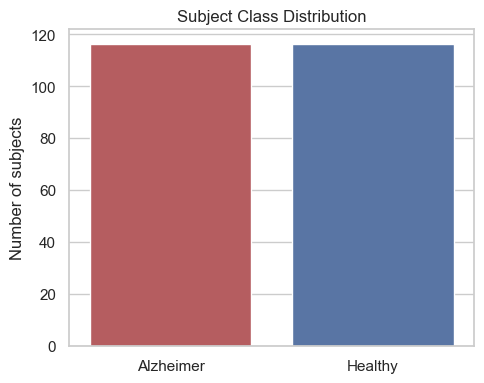

In [7]:
# 5.1 Subject class distribution
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=subject_index, x="class_name", hue="class_name", legend=False,
              palette={"Healthy": "#4C72B0", "Alzheimer": "#C44E52"}, ax=ax)
ax.set_title("Subject Class Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of subjects")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_class_distribution.png")
plt.show()


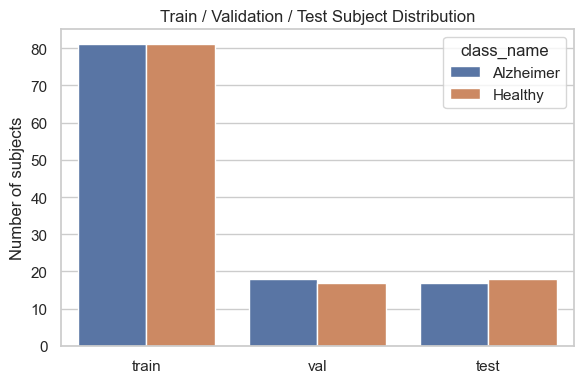

In [8]:
# 5.2 Train / validation / test subject distribution
fig, ax = plt.subplots(figsize=(6, 4))
split_counts = subject_index.groupby(["split", "class_name"]).size().reset_index(name="count")
sns.barplot(data=split_counts, x="split", y="count", hue="class_name",
            order=["train", "val", "test"], ax=ax)
ax.set_title("Train / Validation / Test Subject Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of subjects")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_split_distribution.png")
plt.show()


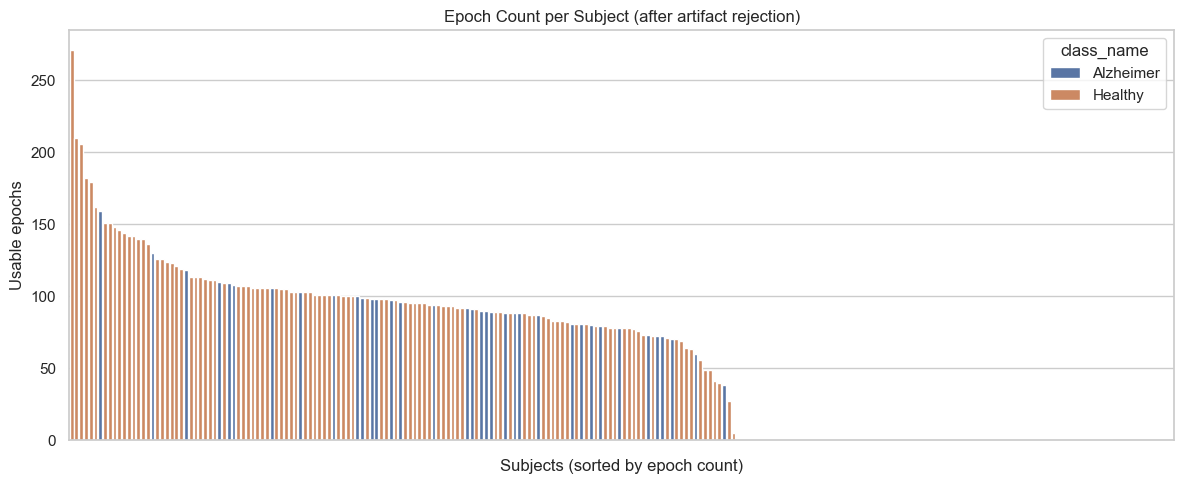

count    232.000000
mean      60.409483
std       54.820451
min        0.000000
25%        1.000000
50%       78.000000
75%      100.000000
max      271.000000
Name: n_epochs, dtype: float64


In [9]:
# 5.3 Epoch count per subject
fig, ax = plt.subplots(figsize=(12, 5))
order = subject_epoch_df.sort_values("n_epochs", ascending=False)["subject_id"]
sns.barplot(data=subject_epoch_df, x="subject_id", y="n_epochs", hue="class_name",
            order=order, ax=ax, dodge=False)
ax.set_xticklabels([])
ax.set_xlabel("Subjects (sorted by epoch count)")
ax.set_ylabel("Usable epochs")
ax.set_title("Epoch Count per Subject (after artifact rejection)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_epoch_count_per_subject.png")
plt.show()

print(subject_epoch_df["n_epochs"].describe())


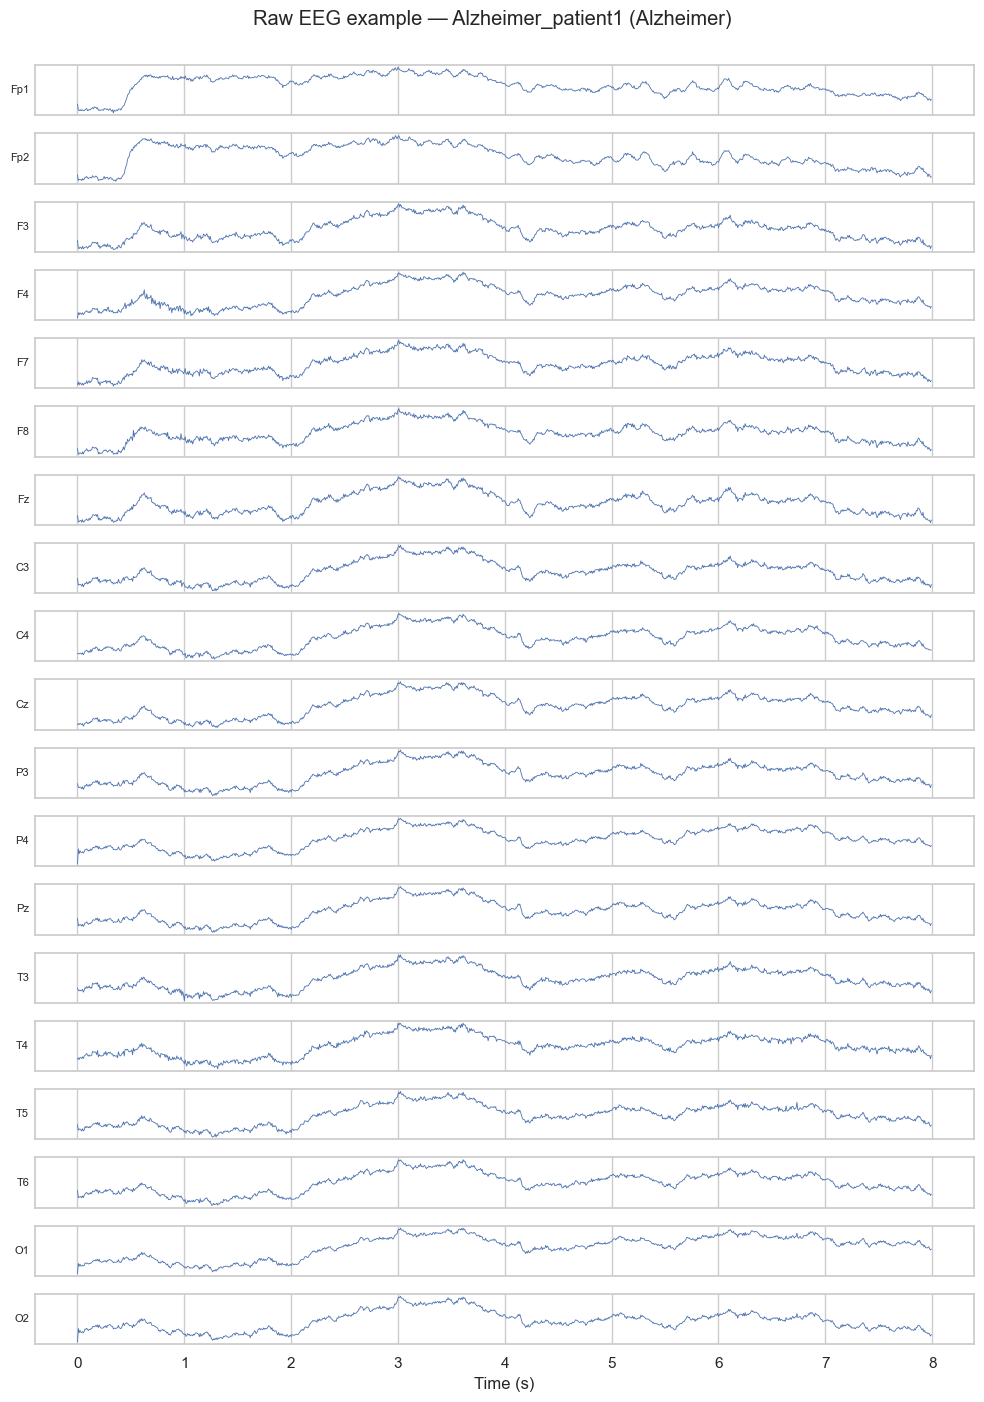

In [10]:
# 5.4 Raw EEG example (first 8 seconds, all channels)
t = np.arange(EPOCH_SAMPLES) / FS
fig, axes = plt.subplots(N_CHANNELS, 1, figsize=(10, 14), sharex=True)
for i, ch in enumerate(CHANNELS):
    seg = example_raw[i, :EPOCH_SAMPLES]
    axes[i].plot(t, seg, linewidth=0.6)
    axes[i].set_ylabel(ch, rotation=0, ha="right", va="center", fontsize=8)
    axes[i].set_yticks([])
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Raw EEG example — {example_subject_name} "
             f"({'Alzheimer' if example_label == 1 else 'Healthy'})", y=1.0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_raw_eeg_example.png")
plt.show()


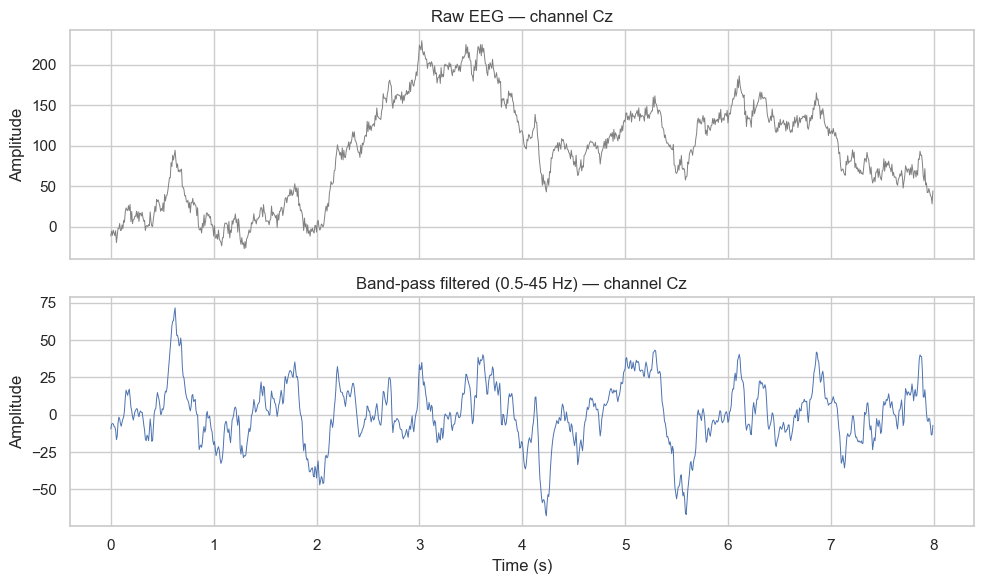

In [11]:
# 5.5 Filtered EEG example + 5.6 raw vs. filtered comparison (single channel, e.g. Cz)
ch_idx = CHANNELS.index("Cz")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, example_raw[ch_idx, :EPOCH_SAMPLES], color="gray", linewidth=0.7)
axes[0].set_title(f"Raw EEG — channel {CHANNELS[ch_idx]}")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, example_filtered[ch_idx, :EPOCH_SAMPLES], color="#4C72B0", linewidth=0.7)
axes[1].set_title(f"Band-pass filtered ({BAND[0]}-{BAND[1]} Hz) — channel {CHANNELS[ch_idx]}")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_raw_vs_filtered.png")
plt.show()


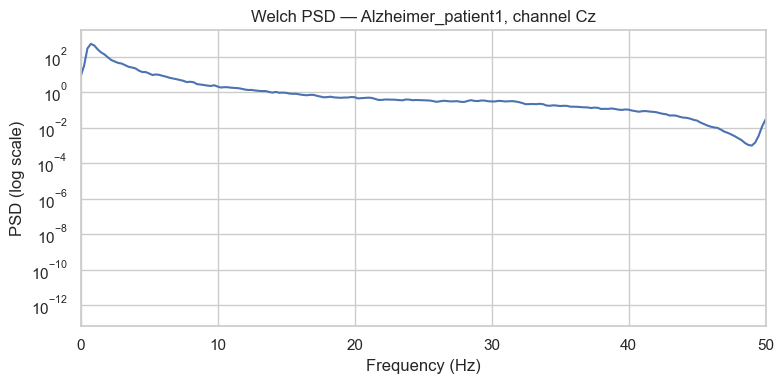

In [12]:
# 5.7 Welch PSD example
def welch_psd(signal_1d: np.ndarray, fs: int = FS, nperseg: int = 512):
    nperseg = min(nperseg, len(signal_1d))
    freqs, psd = welch(signal_1d, fs=fs, nperseg=nperseg)
    return freqs, psd

freqs_ex, psd_ex = welch_psd(example_filtered[ch_idx])
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(freqs_ex, psd_ex)
ax.set_xlim(0, 50)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (log scale)")
ax.set_title(f"Welch PSD — {example_subject_name}, channel {CHANNELS[ch_idx]}")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_welch_psd_example.png")
plt.show()


In [13]:
# Band power helper functions (used again later for baseline features)
def band_power_from_psd(freqs: np.ndarray, psd: np.ndarray, band: tuple) -> float:
    idx = (freqs >= band[0]) & (freqs <= band[1])
    if idx.sum() < 2:
        return 0.0
    return float(np.trapz(psd[idx], freqs[idx]))


def compute_band_powers_for_channel(signal_1d: np.ndarray, fs: int = FS):
    """Return dict of absolute and relative band power for one channel signal."""
    freqs, psd = welch_psd(signal_1d, fs=fs)
    total_power = band_power_from_psd(freqs, psd, BAND)
    out = {}
    for band_name, band_range in BANDS.items():
        abs_p = band_power_from_psd(freqs, psd, band_range)
        rel_p = abs_p / total_power if total_power > 1e-12 else 0.0
        out[f"{band_name}_abs"] = abs_p
        out[f"{band_name}_rel"] = rel_p
    return out


print("Band power helpers ready.")


Band power helpers ready.


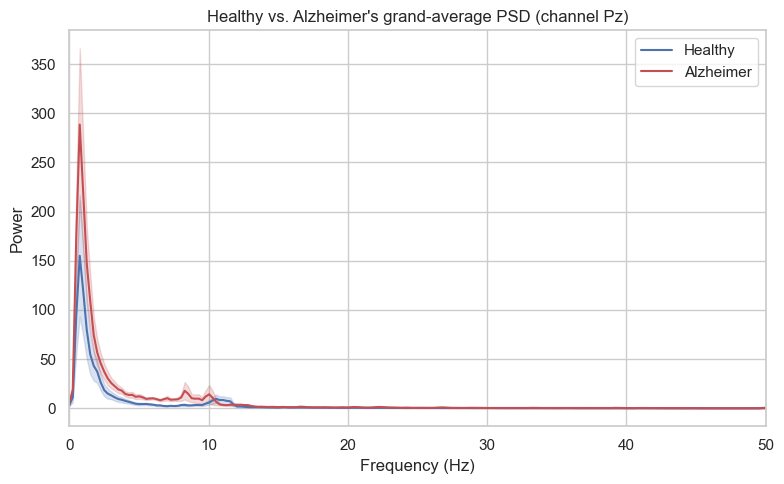

In [14]:
# 5.8 Healthy vs. Alzheimer's PSD comparison (grand-average PSD across a representative channel, Pz)
def subject_concat_channel_signal(subject_row, ch_name: str, max_epochs_for_plot: int = 30):
    """Load + filter + epoch a subject, and return concatenated clean signal for one channel."""
    raw = load_subject_data(Path(subject_row.path))
    filtered = bandpass_filter(raw)
    epochs = create_epochs(filtered)
    clean_epochs, _, _ = reject_artifact_epochs(epochs)
    if clean_epochs.shape[0] == 0:
        return None
    clean_epochs = clean_epochs[:max_epochs_for_plot]
    ch_idx_local = CHANNELS.index(ch_name)
    return clean_epochs[:, :, ch_idx_local].reshape(-1)

psd_curves = {"Healthy": [], "Alzheimer": []}
plot_channel = "Pz"
sample_subjects = subject_index.groupby("class_name").apply(
    lambda g: g.sample(min(15, len(g)), random_state=SEED)
).reset_index(drop=True)

for row in sample_subjects.itertuples(index=False):
    sig = subject_concat_channel_signal(row, plot_channel)
    if sig is None or len(sig) < FS * 2:
        continue
    f_, p_ = welch_psd(sig)
    psd_curves[row.class_name].append(np.interp(np.linspace(0, 50, 200), f_, p_))

fig, ax = plt.subplots(figsize=(8, 5))
freq_grid = np.linspace(0, 50, 200)
for cls_name, color in [("Healthy", "#4C72B0"), ("Alzheimer", "#C44E52")]:
    if len(psd_curves[cls_name]) == 0:
        continue
    arr = np.array(psd_curves[cls_name])
    mean_psd = arr.mean(axis=0)
    sem_psd = arr.std(axis=0) / np.sqrt(arr.shape[0])
    ax.plot(freq_grid, mean_psd, label=cls_name, color=color)
    ax.fill_between(freq_grid, mean_psd - sem_psd, mean_psd + sem_psd, color=color, alpha=0.2)
ax.set_xlim(0, 50)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
ax.set_title(f"Healthy vs. Alzheimer's grand-average PSD (channel {plot_channel})")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_healthy_vs_alzheimer_psd.png")
plt.show()


## 6. Subject-Level Band-Power Feature Extraction

For the classical baseline models we compute, per subject, the absolute and relative band power
(delta, theta, alpha, beta, gamma) for every channel, using the Welch PSD of the subject's
concatenated, artifact-cleaned, filtered epochs. This yields `19 channels x 5 bands x 2 (abs/rel) = 190` features per subject.


In [15]:
def compute_subject_band_feature_vector(clean_epochs: np.ndarray, fs: int = FS) -> dict:
    """clean_epochs: (n_epochs, samples, n_channels) -> flat dict of band-power features."""
    n_epochs, n_samples, n_channels = clean_epochs.shape
    concat = clean_epochs.transpose(2, 0, 1).reshape(n_channels, -1)  # (channels, total_samples)
    features = {}
    for ci, ch in enumerate(CHANNELS):
        ch_feats = compute_band_powers_for_channel(concat[ci], fs=fs)
        for k, v in ch_feats.items():
            features[f"{ch}_{k}"] = v
    return features


def build_feature_table(subject_index_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for row in tqdm(list(subject_index_df.itertuples(index=False)), desc="Extracting band-power features"):
        raw = load_subject_data(Path(row.path))
        filtered = bandpass_filter(raw)
        epochs = create_epochs(filtered)
        clean_epochs, _, _ = reject_artifact_epochs(epochs)
        if clean_epochs.shape[0] == 0:
            continue
        feats = compute_subject_band_feature_vector(clean_epochs)
        feats.update({"subject_id": row.subject_id, "label": row.label, "split": row.split})
        rows.append(feats)
    return pd.DataFrame(rows)


feature_table = build_feature_table(subject_index)
feature_cols = [c for c in feature_table.columns if c not in ("subject_id", "label", "split")]
feature_table.to_csv(RESULTS_DIR / "subject_band_power_features.csv", index=False)
print(f"Feature table shape: {feature_table.shape} ({len(feature_cols)} features per subject)")
feature_table.head()


Extracting band-power features: 100%|██████████| 232/232 [00:32<00:00,  7.16it/s]

Feature table shape: (219, 193) (190 features per subject)


,Fp1_delta_abs,Fp1_delta_rel,Fp1_theta_abs,Fp1_theta_rel,Fp1_alpha_abs,Fp1_alpha_rel,Fp1_beta_abs,Fp1_beta_rel,Fp1_gamma_abs,Fp1_gamma_rel,...,O2_theta_rel,O2_alpha_abs,O2_alpha_rel,O2_beta_abs,O2_beta_rel,O2_gamma_abs,O2_gamma_rel,subject_id,label,split
0,623.352640,0.857293,67.716775,0.093131,15.590264,0.021441,14.360423,0.019750,6.096901,0.008385,...,0.071650,12.519409,0.020788,10.130531,0.016821,2.638716,0.004381,Alzheimer_patient1,1,test
1,501.106999,0.892452,31.868388,0.056756,12.279958,0.021870,11.927689,0.021243,4.311657,0.007679,...,0.060272,23.696761,0.046689,14.576163,0.028719,2.573360,0.005070,Alzheimer_patient10,1,train
2,43.560814,0.506404,24.429108,0.283994,10.894658,0.126653,5.850500,0.068013,1.284872,0.014937,...,0.320429,9.669714,0.111271,3.185452,0.036656,0.395571,0.004552,Alzheimer_patient101,1,train
3,38.065859,0.493742,23.161307,0.300419,9.062109,0.117542,5.798387,0.075209,1.009004,0.013088,...,0.463299,9.364604,0.096505,3.081268,0.031753,0.386574,0.003984,Alzheimer_patient102,1,val
4,42.727176,0.496924,20.347748,0.236647,15.525672,0.180566,6.172929,0.071792,1.209866,0.014071,...,0.424055,15.117998,0.149951,2.819905,0.027970,0.411210,0.004079,Alzheimer_patient103,1,train


## 7. Normalization

Two independent normalizations are used in this notebook, and both strictly follow **train-only
fitting**:

1. **Epoch-level z-score normalization** for the deep learning models, computed per channel using
   training epochs only, then applied identically to validation and test epochs.
2. **Feature-level scaling** for the baseline models, handled inside `sklearn` `Pipeline`s so that
   `StandardScaler` is fit only on each training fold.

Test-set statistics are never used for normalization anywhere in this notebook.


In [16]:
# Epoch-level normalization (per channel), fit on TRAIN epochs only
train_mean = epoch_data["train"].mean(axis=(0, 1), keepdims=True)   # (1,1,n_channels)
train_std = epoch_data["train"].std(axis=(0, 1), keepdims=True) + 1e-8

norm_epoch_data = {}
for split in ("train", "val", "test"):
    norm_epoch_data[split] = ((epoch_data[split] - train_mean) / train_std).astype(np.float32)

np.savez(RESULTS_DIR / "normalization_stats.npz",
         mean=train_mean, std=train_std, channels=np.array(CHANNELS))

print("Per-channel training mean/std computed and applied to train/val/test epochs.")
print("Train mean range:", train_mean.min(), "to", train_mean.max())
print("Train std range:", train_std.min(), "to", train_std.max())


Per-channel training mean/std computed and applied to train/val/test epochs.
Train mean range: -0.0011730503 to 0.0029449814
Train std range: 16.757265 to 19.684017


## 8. Baseline Models (Subject-Level Band-Power Features)

We train three classical baselines — Logistic Regression, SVM, and Random Forest — using
`sklearn` `Pipeline`s so that feature scaling is always fit on the training fold only.


In [17]:
X_train_feat = feature_table.loc[feature_table.split == "train", feature_cols].values
y_train_feat = feature_table.loc[feature_table.split == "train", "label"].values
X_val_feat = feature_table.loc[feature_table.split == "val", feature_cols].values
y_val_feat = feature_table.loc[feature_table.split == "val", "label"].values
X_test_feat = feature_table.loc[feature_table.split == "test", feature_cols].values
y_test_feat = feature_table.loc[feature_table.split == "test", "label"].values

baseline_pipelines = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced", random_state=SEED)),
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                     class_weight="balanced", random_state=SEED)),
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=None,
                                        class_weight="balanced", random_state=SEED, n_jobs=-1)),
    ]),
}

baseline_fitted = {}
baseline_test_probs = {}
for name, pipe in baseline_pipelines.items():
    pipe.fit(X_train_feat, y_train_feat)
    baseline_fitted[name] = pipe
    baseline_test_probs[name] = pipe.predict_proba(X_test_feat)[:, 1]
    val_auc = roc_auc_score(y_val_feat, pipe.predict_proba(X_val_feat)[:, 1])
    print(f"{name}: validation ROC-AUC = {val_auc:.4f}")


LogisticRegression: validation ROC-AUC = 0.9882
SVM: validation ROC-AUC = 0.9922
RandomForest: validation ROC-AUC = 0.9706


## 9. Deep Learning Models

Both models take raw (normalized) epochs of shape `(1024, 19)` and output a single sigmoid
probability of Alzheimer's Disease per epoch.

### Model A — EEGNet-inspired CNN
Temporal convolution → depthwise spatial convolution → separable convolution, with batch
normalization and dropout throughout — the classic compact EEGNet recipe.

### Model B — Improved DNN
Temporal CNN stem → separable-convolution residual blocks → lightweight squeeze-and-excite
attention → global pooling → dense head with L2 regularization, dropout, and early stopping.


In [18]:
def build_eegnet(n_channels=N_CHANNELS, n_samples=EPOCH_SAMPLES,
                  F1=8, D=2, F2=16, kern_length=64, dropout_rate=0.4):
    """
    EEGNet-inspired compact CNN.
    Input: (n_channels, n_samples, 1) — channels-first spatial layout for the depthwise conv.
    """
    inp = layers.Input(shape=(n_channels, n_samples, 1), name="eeg_input")

    # Block 1: temporal convolution
    x = layers.Conv2D(F1, (1, kern_length), padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)

    # Depthwise convolution across channels (spatial filter)
    x = layers.DepthwiseConv2D((n_channels, 1), use_bias=False, depth_multiplier=D,
                                depthwise_constraint=tf.keras.constraints.max_norm(1.0))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 4))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Separable convolution
    x = layers.SeparableConv2D(F2, (1, 16), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 8))(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid",
                        kernel_constraint=tf.keras.constraints.max_norm(0.25))(x)

    model = models.Model(inputs=inp, outputs=out, name="EEGNet")
    return model


eegnet_model = build_eegnet()
eegnet_model.summary()


Model: "EEGNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 19, 1024, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 19, 1024, 8)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 1024, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 1024, 16)    │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1024, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 1024, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 256, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 256, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 256, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 256, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 32, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 32, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 1,921 (7.50 KB)

 Non-trainable params: 80 (320.00 B)

In [19]:
def se_attention_block(x, reduction=8, name_prefix="se"):
    """Lightweight squeeze-and-excite channel attention for a (time, filters) tensor."""
    n_filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    se = layers.Dense(max(n_filters // reduction, 4), activation="relu",
                       name=f"{name_prefix}_fc1")(se)
    se = layers.Dense(n_filters, activation="sigmoid", name=f"{name_prefix}_fc2")(se)
    se = layers.Reshape((1, n_filters))(se)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, se])


def residual_sep_conv_block(x, filters, kernel_size=7, l2_reg=1e-4, dropout_rate=0.3, name_prefix="res"):
    shortcut = x
    y = layers.Conv1D(filters, kernel_size, padding="same",
                       kernel_regularizer=regularizers.l2(l2_reg),
                       name=f"{name_prefix}_conv1")(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)
    y = layers.SeparableConv1D(filters, kernel_size, padding="same",
                                depthwise_regularizer=regularizers.l2(l2_reg),
                                pointwise_regularizer=regularizers.l2(l2_reg),
                                name=f"{name_prefix}_sepconv")(y)
    y = layers.BatchNormalization()(y)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same", name=f"{name_prefix}_proj")(shortcut)

    out = layers.Add(name=f"{name_prefix}_add")([shortcut, y])
    out = layers.Activation("relu")(out)
    out = layers.Dropout(dropout_rate)(out)
    return out


def build_improved_dnn(n_channels=N_CHANNELS, n_samples=EPOCH_SAMPLES,
                        l2_reg=1e-4, dropout_rate=0.35):
    """
    Improved compact DNN: temporal CNN stem + separable-conv residual blocks +
    lightweight SE attention + dense head with L2 regularization and dropout.
    """
    inp = layers.Input(shape=(n_samples, n_channels), name="eeg_input")

    x = layers.Conv1D(32, 9, strides=2, padding="same",
                       kernel_regularizer=regularizers.l2(l2_reg), name="stem_conv")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = residual_sep_conv_block(x, 32, kernel_size=7, l2_reg=l2_reg,
                                 dropout_rate=dropout_rate, name_prefix="res1")
    x = layers.MaxPooling1D(2)(x)

    x = residual_sep_conv_block(x, 64, kernel_size=5, l2_reg=l2_reg,
                                 dropout_rate=dropout_rate, name_prefix="res2")
    x = layers.MaxPooling1D(2)(x)

    x = residual_sep_conv_block(x, 96, kernel_size=3, l2_reg=l2_reg,
                                 dropout_rate=dropout_rate, name_prefix="res3")

    x = se_attention_block(x, reduction=8, name_prefix="se_attn")

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inp, outputs=out, name="ImprovedDNN")
    return model


improved_dnn_model = build_improved_dnn()
improved_dnn_model.summary()


Model: "ImprovedDNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 1024, 19)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 512, 32)   │      5,504 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 32)   │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 512, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 256, 32)   │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv1 (Conv1D) │ (None, 256, 32)   │      7,200 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ res1_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_sepconv        │ (None, 256, 32)   │      1,280 │ activation_3[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 32)   │        128 │ res1_sepconv[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 256, 32)   │          0 │ max_pooling1d[0]… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 256, 32)   │          0 │ res1_add[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256, 32)   │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 128, 32)   │          0 │ dropout_2[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv1 (Conv1D) │ (None, 128, 64)   │     10,304 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ res2_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 128, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_sepconv        │ (None, 128, 64)   │      4,480 │ activation_5[0][… │
│ (SeparableConv1D)   │                   │            │                 

 Total params: 75,597 (295.30 KB)

 Trainable params: 74,765 (292.05 KB)

 Non-trainable params: 832 (3.25 KB)

## 10. Training

Both networks are trained with `Adam`, monitored on **validation ROC-AUC**, using
`EarlyStopping`, `ReduceLROnPlateau`, and `ModelCheckpoint`. Class weights compensate for any
train-set imbalance. Test data is never touched during training or model selection.


In [20]:
def make_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, weights)}


def reshape_for_eegnet(X):
    """(n_epochs, samples, channels) -> (n_epochs, channels, samples, 1)"""
    return np.transpose(X, (0, 2, 1))[..., np.newaxis]


X_train_dnn, y_train_dnn = norm_epoch_data["train"], epoch_labels["train"]
X_val_dnn, y_val_dnn = norm_epoch_data["val"], epoch_labels["val"]
X_test_dnn, y_test_dnn = norm_epoch_data["test"], epoch_labels["test"]

X_train_eegnet = reshape_for_eegnet(X_train_dnn)
X_val_eegnet = reshape_for_eegnet(X_val_dnn)
X_test_eegnet = reshape_for_eegnet(X_test_dnn)

class_weights = make_class_weights(y_train_dnn)
print("Class weights (train epochs):", class_weights)

BATCH_SIZE = 32
MAX_EPOCHS = 100


def get_callbacks(checkpoint_path):
    return [
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=15,
                                 restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5,
                                     patience=6, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(str(checkpoint_path), monitor="val_auc", mode="max",
                                   save_best_only=True, verbose=0),
    ]


metrics_list = [tf.keras.metrics.AUC(name="auc"), "accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]


Class weights (train epochs): {0: 0.6343104596935376, 1: 2.361359126984127}


In [21]:
# --- Train EEGNet ---
eegnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                      loss="binary_crossentropy", metrics=metrics_list)

eegnet_ckpt_path = MODELS_DIR / "best_eegnet.keras"
eegnet_history = eegnet_model.fit(
    X_train_eegnet, y_train_dnn,
    validation_data=(X_val_eegnet, y_val_dnn),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks(eegnet_ckpt_path),
    verbose=2,
)


Epoch 1/100
298/298 - 20s - 67ms/step - accuracy: 0.7605 - auc: 0.8573 - loss: 0.4464 - precision: 0.4674 - recall: 0.9380 - val_accuracy: 0.8826 - val_auc: 0.9620 - val_loss: 0.2353 - val_precision: 0.7727 - val_recall: 0.7432 - learning_rate: 0.0010
Epoch 2/100
298/298 - 19s - 64ms/step - accuracy: 0.7806 - auc: 0.9104 - loss: 0.3550 - precision: 0.4904 - recall: 0.9286 - val_accuracy: 0.9006 - val_auc: 0.9711 - val_loss: 0.1792 - val_precision: 0.7370 - val_recall: 0.9290 - learning_rate: 0.0010
Epoch 3/100
298/298 - 19s - 65ms/step - accuracy: 0.7892 - auc: 0.9247 - loss: 0.3254 - precision: 0.5012 - recall: 0.9206 - val_accuracy: 0.8965 - val_auc: 0.9727 - val_loss: 0.1657 - val_precision: 0.7262 - val_recall: 0.9326 - learning_rate: 0.0010
Epoch 4/100
298/298 - 19s - 65ms/step - accuracy: 0.7953 - auc: 0.9289 - loss: 0.3133 - precision: 0.5092 - recall: 0.9162 - val_accuracy: 0.9105 - val_auc: 0.9768 - val_loss: 0.1677 - val_precision: 0.9510 - val_recall: 0.6721 - learning_rate:

In [22]:
# --- Train Improved DNN ---
improved_dnn_model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
                            loss="binary_crossentropy", metrics=metrics_list)

dnn_ckpt_path = MODELS_DIR / "best_dnn.keras"
dnn_history = improved_dnn_model.fit(
    X_train_dnn, y_train_dnn,
    validation_data=(X_val_dnn, y_val_dnn),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks(dnn_ckpt_path),
    verbose=2,
)


Epoch 1/100
298/298 - 10s - 35ms/step - accuracy: 0.8451 - auc: 0.9533 - loss: 0.3377 - precision: 0.6370 - recall: 0.9583 - val_accuracy: 0.8718 - val_auc: 0.9973 - val_loss: 0.2579 - val_precision: 1.0000 - val_recall: 0.4809 - learning_rate: 0.0010
Epoch 2/100
298/298 - 7s - 23ms/step - accuracy: 0.9181 - auc: 0.9771 - loss: 0.2171 - precision: 0.7373 - recall: 0.9524 - val_accuracy: 0.9847 - val_auc: 0.9987 - val_loss: 0.1192 - val_precision: 0.9886 - val_recall: 0.9490 - learning_rate: 0.0010
Epoch 3/100
298/298 - 7s - 24ms/step - accuracy: 0.9317 - auc: 0.9829 - loss: 0.1898 - precision: 0.7747 - recall: 0.9554 - val_accuracy: 0.7917 - val_auc: 0.9592 - val_loss: 0.6828 - val_precision: 0.9886 - val_recall: 0.1585 - learning_rate: 0.0010
Epoch 4/100
298/298 - 7s - 24ms/step - accuracy: 0.9475 - auc: 0.9882 - loss: 0.1533 - precision: 0.8164 - recall: 0.9702 - val_accuracy: 0.8309 - val_auc: 0.9985 - val_loss: 0.4102 - val_precision: 0.9943 - val_recall: 0.3169 - learning_rate: 0.

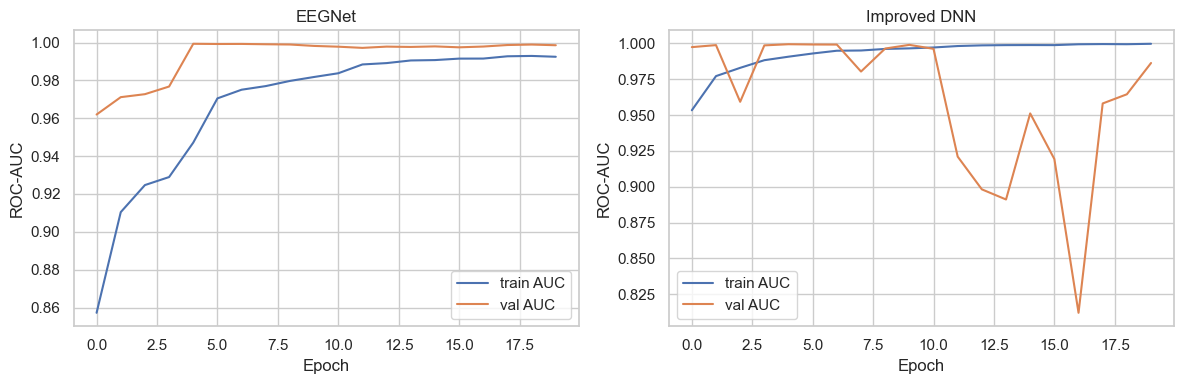

In [23]:
# Reload best checkpoints (ModelCheckpoint already restores best weights via EarlyStopping,
# but we reload from disk to guarantee we evaluate exactly what was saved to disk).
eegnet_model = tf.keras.models.load_model(eegnet_ckpt_path)
improved_dnn_model = tf.keras.models.load_model(dnn_ckpt_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, title in zip(axes, [eegnet_history, dnn_history], ["EEGNet", "Improved DNN"]):
    ax.plot(hist.history["auc"], label="train AUC")
    ax.plot(hist.history["val_auc"], label="val AUC")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("ROC-AUC")
    ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_training_curves.png")
plt.show()


## 11. Subject-Level Prediction: Aggregating Epoch Probabilities

Each deep-learning model predicts a probability **per epoch**. We aggregate these into one
probability **per subject** using three candidate methods:

1. **Mean** probability across a subject's epochs.
2. **Median** probability across a subject's epochs.
3. **Majority vote** of thresholded epoch predictions.

The aggregation method **and** the decision threshold are selected using **validation data only**
(optimizing balanced accuracy), then **frozen** before any test-set evaluation.


In [24]:
def epoch_probs_to_subject_probs(epoch_probs, subject_ids, method="mean"):
    df = pd.DataFrame({"subject_id": subject_ids, "prob": epoch_probs})
    if method == "mean":
        return df.groupby("subject_id")["prob"].mean()
    elif method == "median":
        return df.groupby("subject_id")["prob"].median()
    elif method == "majority_vote":
        # vote at threshold 0.5 first, then report the vote fraction as a pseudo-probability
        df["vote"] = (df["prob"] >= 0.5).astype(int)
        return df.groupby("subject_id")["vote"].mean()
    else:
        raise ValueError(f"Unknown aggregation method: {method}")


def subject_labels_from_ids(subject_ids, subject_id_to_label):
    unique_ids = pd.unique(subject_ids)
    return pd.Series({sid: subject_id_to_label[sid] for sid in unique_ids})


subject_id_to_label = dict(zip(subject_index["subject_id"], subject_index["label"]))

def select_aggregation_and_threshold(val_epoch_probs, val_subject_ids):
    """Grid-search aggregation method x threshold on VALIDATION data, optimizing balanced accuracy."""
    best = {"method": None, "threshold": None, "balanced_acc": -1.0}
    methods = ["mean", "median", "majority_vote"]
    thresholds = np.linspace(0.05, 0.95, 91)

    for method in methods:
        subj_probs = epoch_probs_to_subject_probs(val_epoch_probs, val_subject_ids, method=method)
        y_true = subject_labels_from_ids(val_subject_ids, subject_id_to_label).loc[subj_probs.index]
        for thr in thresholds:
            y_pred = (subj_probs.values >= thr).astype(int)
            bal_acc = balanced_accuracy_score(y_true.values, y_pred)
            if bal_acc > best["balanced_acc"]:
                best.update({"method": method, "threshold": float(thr), "balanced_acc": bal_acc})
    return best


def get_epoch_probs(model, X_eegnet_or_dnn, is_eegnet=False):
    return model.predict(X_eegnet_or_dnn, verbose=0).ravel()


eegnet_val_probs = get_epoch_probs(eegnet_model, X_val_eegnet)
dnn_val_probs = get_epoch_probs(improved_dnn_model, X_val_dnn)

eegnet_best_agg = select_aggregation_and_threshold(eegnet_val_probs, epoch_subject_ids["val"])
dnn_best_agg = select_aggregation_and_threshold(dnn_val_probs, epoch_subject_ids["val"])

print("EEGNet frozen aggregation/threshold:", eegnet_best_agg)
print("Improved DNN frozen aggregation/threshold:", dnn_best_agg)


EEGNet frozen aggregation/threshold: {'method': 'mean', 'threshold': 0.22999999999999998, 'balanced_acc': 1.0}
Improved DNN frozen aggregation/threshold: {'method': 'mean', 'threshold': 0.07, 'balanced_acc': 0.9705882352941176}


## 12. Metrics

We compute a comprehensive metric set at both the epoch level (secondary) and subject level
(primary): accuracy, balanced accuracy, sensitivity, specificity, precision, F1, ROC-AUC, PR-AUC,
MCC, Cohen's Kappa, Brier score, and the confusion-matrix counts (TN/FP/FN/TP).


In [25]:
def compute_full_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_prob),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "n_subjects": len(y_true),
    }
    return out


def evaluate_dl_model_subject_level(model, X_test, y_test_epoch, test_subject_ids, agg_cfg):
    test_epoch_probs = get_epoch_probs(model, X_test)
    subj_probs = epoch_probs_to_subject_probs(test_epoch_probs, test_subject_ids, method=agg_cfg["method"])
    y_true_subj = subject_labels_from_ids(test_subject_ids, subject_id_to_label).loc[subj_probs.index]
    y_pred_subj = (subj_probs.values >= agg_cfg["threshold"]).astype(int)

    subj_metrics = compute_full_metrics(y_true_subj.values, y_pred_subj, subj_probs.values)

    y_pred_epoch = (test_epoch_probs >= 0.5).astype(int)
    epoch_metrics = compute_full_metrics(y_test_epoch, y_pred_epoch, test_epoch_probs)

    return subj_metrics, epoch_metrics, subj_probs, y_true_subj, y_pred_subj, test_epoch_probs


eegnet_subj_metrics, eegnet_epoch_metrics, eegnet_subj_probs, eegnet_y_true_subj, \
    eegnet_y_pred_subj, eegnet_test_epoch_probs = evaluate_dl_model_subject_level(
        eegnet_model, X_test_eegnet, y_test_dnn, epoch_subject_ids["test"], eegnet_best_agg)

dnn_subj_metrics, dnn_epoch_metrics, dnn_subj_probs, dnn_y_true_subj, \
    dnn_y_pred_subj, dnn_test_epoch_probs = evaluate_dl_model_subject_level(
        improved_dnn_model, X_test_dnn, y_test_dnn, epoch_subject_ids["test"], dnn_best_agg)

print("EEGNet   — subject-level test metrics:", eegnet_subj_metrics)
print("ImprovedDNN — subject-level test metrics:", dnn_subj_metrics)


EEGNet   — subject-level test metrics: {'accuracy': 0.8529411764705882, 'balanced_accuracy': 0.8611111111111112, 'sensitivity_recall': 1.0, 'specificity': np.float64(0.7222222222222222), 'precision': 0.7619047619047619, 'f1': 0.8648648648648649, 'roc_auc': 0.9409722222222222, 'pr_auc': 0.9392113095238095, 'mcc': 0.7417981870189158, 'cohen_kappa': 0.7098976109215016, 'brier_score': 0.10200358138564936, 'TN': 13, 'FP': 5, 'FN': 0, 'TP': 16, 'n_subjects': 34}
ImprovedDNN — subject-level test metrics: {'accuracy': 0.8529411764705882, 'balanced_accuracy': 0.8576388888888888, 'sensitivity_recall': 0.9375, 'specificity': np.float64(0.7777777777777778), 'precision': 0.7894736842105263, 'f1': 0.8571428571428571, 'roc_auc': 0.9513888888888888, 'pr_auc': 0.9458917920314979, 'mcc': 0.7190325425674107, 'cohen_kappa': 0.7079037800687284, 'brier_score': 0.1123378206307663, 'TN': 14, 'FP': 4, 'FN': 1, 'TP': 15, 'n_subjects': 34}


In [26]:
# Baseline models are naturally subject-level already (one feature vector per subject)
baseline_subj_metrics = {}
baseline_subj_preds = {}
baseline_thresholds = {}

for name, pipe in baseline_fitted.items():
    val_probs = pipe.predict_proba(X_val_feat)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 91)
    best_thr, best_bal_acc = 0.5, -1
    for thr in thresholds:
        bal_acc = balanced_accuracy_score(y_val_feat, (val_probs >= thr).astype(int))
        if bal_acc > best_bal_acc:
            best_thr, best_bal_acc = thr, bal_acc
    baseline_thresholds[name] = best_thr

    test_probs = baseline_test_probs[name]
    test_pred = (test_probs >= best_thr).astype(int)
    baseline_subj_metrics[name] = compute_full_metrics(y_test_feat, test_pred, test_probs)
    baseline_subj_preds[name] = test_pred
    print(f"{name}: frozen threshold={best_thr:.2f} -> "
          f"test balanced accuracy={baseline_subj_metrics[name]['balanced_accuracy']:.4f}")


LogisticRegression: frozen threshold=0.05 -> test balanced accuracy=0.8021
SVM: frozen threshold=0.70 -> test balanced accuracy=0.8160
RandomForest: frozen threshold=0.32 -> test balanced accuracy=0.8264


Best deep-learning model on test ROC-AUC: ImprovedDNN


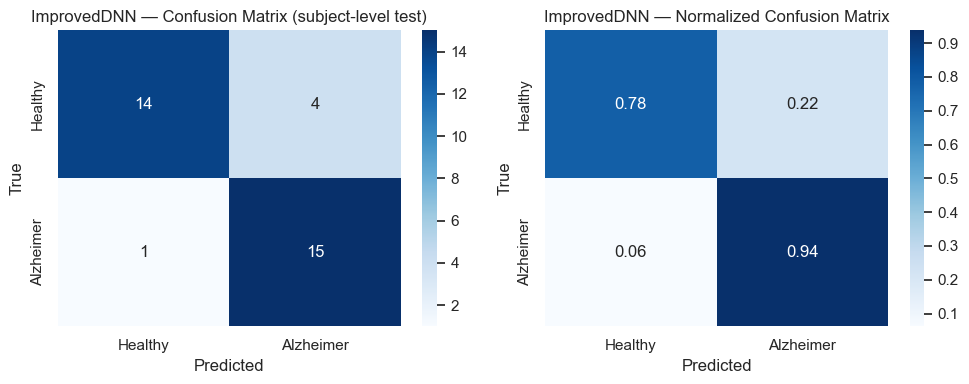

In [27]:
# 12.x Confusion matrices, ROC, PR, calibration, threshold plots for the best DL model
best_dl_name = "EEGNet" if eegnet_subj_metrics["roc_auc"] >= dnn_subj_metrics["roc_auc"] else "ImprovedDNN"
best_dl_probs = eegnet_subj_probs if best_dl_name == "EEGNet" else dnn_subj_probs
best_dl_y_true = eegnet_y_true_subj if best_dl_name == "EEGNet" else dnn_y_true_subj
best_dl_y_pred = eegnet_y_pred_subj if best_dl_name == "EEGNet" else dnn_y_pred_subj
best_dl_agg_cfg = eegnet_best_agg if best_dl_name == "EEGNet" else dnn_best_agg
print(f"Best deep-learning model on test ROC-AUC: {best_dl_name}")

cm = confusion_matrix(best_dl_y_true.values, best_dl_y_pred, labels=[0, 1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy", "Alzheimer"],
            yticklabels=["Healthy", "Alzheimer"], ax=axes[0])
axes[0].set_title(f"{best_dl_name} — Confusion Matrix (subject-level test)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=["Healthy", "Alzheimer"],
            yticklabels=["Healthy", "Alzheimer"], ax=axes[1])
axes[1].set_title(f"{best_dl_name} — Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_confusion_matrices.png")
plt.show()


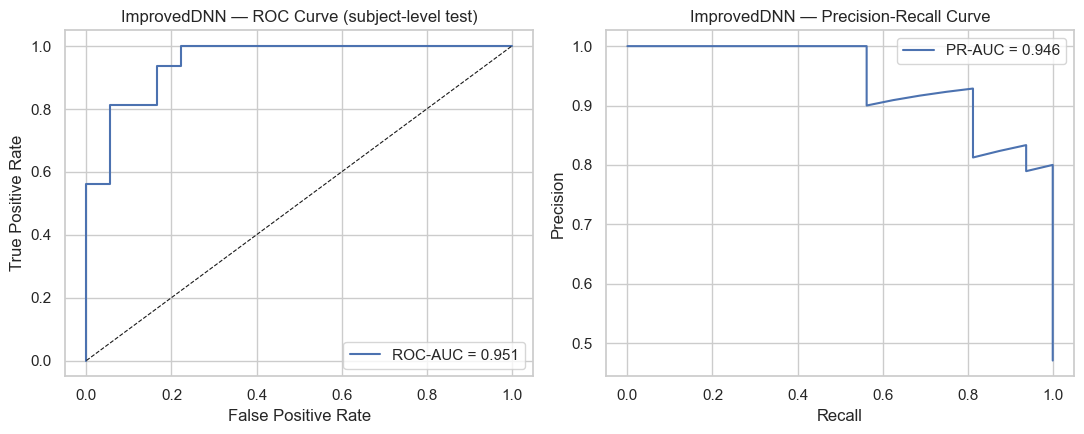

In [28]:
fpr, tpr, _ = roc_curve(best_dl_y_true.values, best_dl_probs.values)
prec, rec, _ = precision_recall_curve(best_dl_y_true.values, best_dl_probs.values)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {eegnet_subj_metrics['roc_auc'] if best_dl_name=='EEGNet' else dnn_subj_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"{best_dl_name} — ROC Curve (subject-level test)")
axes[0].legend()

axes[1].plot(rec, prec, label=f"PR-AUC = {eegnet_subj_metrics['pr_auc'] if best_dl_name=='EEGNet' else dnn_subj_metrics['pr_auc']:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title(f"{best_dl_name} — Precision-Recall Curve")
axes[1].legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "10_roc_pr_curves.png")
plt.show()


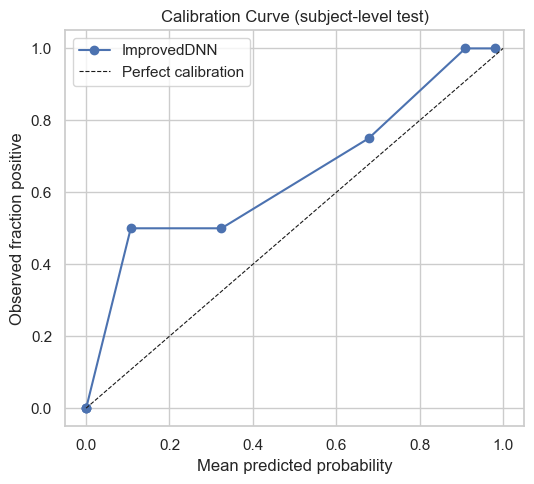

In [29]:
# Calibration curve
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(best_dl_y_true.values, best_dl_probs.values, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(mean_pred, frac_pos, marker="o", label=best_dl_name)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration Curve (subject-level test)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "11_calibration_curve.png")
plt.show()


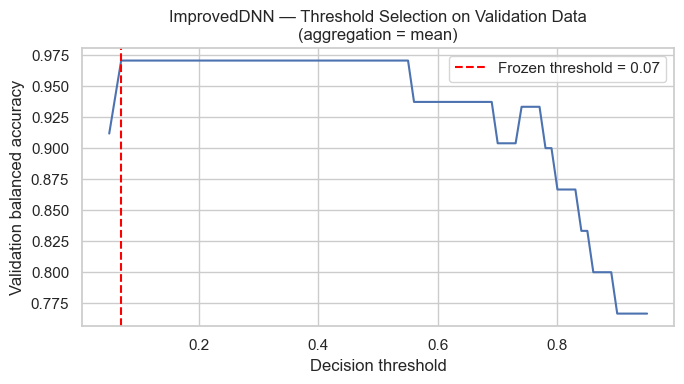

In [30]:
# Threshold vs. validation balanced accuracy plot (for the best DL model's chosen aggregation)
val_epoch_probs_best = eegnet_val_probs if best_dl_name == "EEGNet" else dnn_val_probs
val_subj_probs_best = epoch_probs_to_subject_probs(
    val_epoch_probs_best, epoch_subject_ids["val"], method=best_dl_agg_cfg["method"])
val_y_true_best = subject_labels_from_ids(epoch_subject_ids["val"], subject_id_to_label).loc[val_subj_probs_best.index]

thresholds = np.linspace(0.05, 0.95, 91)
bal_accs = [balanced_accuracy_score(val_y_true_best.values, (val_subj_probs_best.values >= t).astype(int))
            for t in thresholds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, bal_accs)
ax.axvline(best_dl_agg_cfg["threshold"], color="red", linestyle="--",
           label=f"Frozen threshold = {best_dl_agg_cfg['threshold']:.2f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Validation balanced accuracy")
ax.set_title(f"{best_dl_name} — Threshold Selection on Validation Data\n(aggregation = {best_dl_agg_cfg['method']})")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "12_threshold_vs_val_balanced_accuracy.png")
plt.show()


## 13. Subject-Level Bootstrap Confidence Intervals

We compute 95% bootstrap confidence intervals (~1000 resamples) for accuracy, balanced accuracy,
sensitivity, specificity, and ROC-AUC on the **test-set subjects**, for the best deep-learning
model.


In [31]:
def bootstrap_ci(y_true, y_pred, y_prob, n_boot=1000, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    metric_samples = {"accuracy": [], "balanced_accuracy": [], "sensitivity": [],
                       "specificity": [], "roc_auc": []}

    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); y_prob = np.asarray(y_prob)

    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        metric_samples["accuracy"].append(accuracy_score(yt, yp))
        metric_samples["balanced_accuracy"].append(balanced_accuracy_score(yt, yp))
        metric_samples["sensitivity"].append(sens)
        metric_samples["specificity"].append(spec)
        metric_samples["roc_auc"].append(roc_auc_score(yt, ypr))

    ci_results = {}
    for metric, samples in metric_samples.items():
        samples = np.array(samples)
        ci_results[metric] = {
            "point_estimate": float(samples.mean()),
            "ci_lower_2.5": float(np.percentile(samples, 2.5)),
            "ci_upper_97.5": float(np.percentile(samples, 97.5)),
        }
    return ci_results


best_dl_ci = bootstrap_ci(best_dl_y_true.values, best_dl_y_pred, best_dl_probs.values, n_boot=1000)
print(f"Bootstrap 95% CIs — {best_dl_name} (subject-level test, n=1000 resamples):")
for metric, vals in best_dl_ci.items():
    print(f"  {metric:18s}: {vals['point_estimate']:.3f}  "
          f"[{vals['ci_lower_2.5']:.3f}, {vals['ci_upper_97.5']:.3f}]")

with open(RESULTS_DIR / "bootstrap_ci.json", "w") as f:
    json.dump({best_dl_name: best_dl_ci}, f, indent=2)


Bootstrap 95% CIs — ImprovedDNN (subject-level test, n=1000 resamples):
  accuracy          : 0.850  [0.735, 0.941]
  balanced_accuracy : 0.854  [0.735, 0.957]
  sensitivity       : 0.932  [0.789, 1.000]
  specificity       : 0.776  [0.588, 0.945]
  roc_auc           : 0.951  [0.872, 1.000]


## 14. Subject-Level 5-Fold Stratified Cross-Validation

`RUN_CV` (baseline models) and `RUN_DL_CV` (deep-learning models) are configurable at the top of
the notebook. No subject is ever split across folds — the split happens on the subject list, and
all of a subject's epochs move with it.


In [32]:
def run_subject_level_cv_baselines(subject_index_df, feature_table_df, feature_cols, k=CV_FOLDS, seed=SEED):
    all_subjects = subject_index_df["subject_id"].values
    all_labels = subject_index_df["label"].values
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

    cv_results = {name: [] for name in baseline_pipelines.keys()}

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(all_subjects, all_labels)):
        fold_train_ids = set(all_subjects[train_idx])
        fold_test_ids = set(all_subjects[test_idx])
        assert fold_train_ids.isdisjoint(fold_test_ids), "CV leakage detected!"

        ft_train = feature_table_df[feature_table_df.subject_id.isin(fold_train_ids)]
        ft_test = feature_table_df[feature_table_df.subject_id.isin(fold_test_ids)]

        Xtr, ytr = ft_train[feature_cols].values, ft_train["label"].values
        Xte, yte = ft_test[feature_cols].values, ft_test["label"].values

        for name, pipe_template in baseline_pipelines.items():
            pipe = Pipeline([(s, type(t)(**t.get_params())) if False else (s, t)
                              for s, t in pipe_template.steps])
            # Fresh clone to avoid re-using fitted state across folds
            from sklearn.base import clone
            pipe = clone(pipe_template)
            pipe.fit(Xtr, ytr)
            probs = pipe.predict_proba(Xte)[:, 1]
            preds = (probs >= 0.5).astype(int)
            m = compute_full_metrics(yte, preds, probs)
            m["fold"] = fold_i
            cv_results[name].append(m)

    return cv_results


if RUN_CV:
    cv_results = run_subject_level_cv_baselines(subject_index, feature_table, feature_cols)
    cv_summary_rows = []
    for name, fold_metrics in cv_results.items():
        df_cv = pd.DataFrame(fold_metrics)
        for metric in ["accuracy", "balanced_accuracy", "sensitivity_recall", "specificity",
                       "f1", "roc_auc", "pr_auc", "mcc"]:
            cv_summary_rows.append({
                "model": name, "metric": metric,
                "mean": df_cv[metric].mean(), "std": df_cv[metric].std(),
            })
    cv_summary_df = pd.DataFrame(cv_summary_rows)
    cv_summary_df.to_csv(RESULTS_DIR / "cv_baseline_summary.csv", index=False)
    print(cv_summary_df.pivot(index="model", columns="metric", values="mean").round(3))
else:
    print("RUN_CV is False — skipping baseline cross-validation.")


metric              accuracy  balanced_accuracy     f1    mcc  pr_auc  \
model                                                                   
LogisticRegression     0.914              0.914  0.912  0.829   0.954   
RandomForest           0.918              0.918  0.917  0.837   0.978   
SVM                    0.899              0.899  0.895  0.800   0.975   

metric              roc_auc  sensitivity_recall  specificity  
model                                                         
LogisticRegression    0.967               0.924        0.904  
RandomForest          0.977               0.933        0.903  
SVM                   0.973               0.895        0.904  


In [37]:
def run_subject_level_cv_dnn(subject_index_df, k=CV_FOLDS, seed=SEED, max_epochs=30):
    """Optional, expensive: retrains the Improved DNN across k subject-level folds."""
    all_subjects = subject_index_df["subject_id"].values
    all_labels = subject_index_df["label"].values
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    fold_metrics = []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(all_subjects, all_labels)):
        fold_train_ids = set(all_subjects[train_idx])
        fold_test_ids = set(all_subjects[test_idx])
        assert fold_train_ids.isdisjoint(fold_test_ids), "CV leakage detected!"

        fold_index = subject_index_df.copy()
        fold_index["cv_split"] = fold_index["subject_id"].apply(
            lambda s: "test" if s in fold_test_ids else "train")

        Xtr_list, ytr_list, sidtr_list = [], [], []
        Xte_list, yte_list, sidte_list = [], [], []
        for row in fold_index.itertuples(index=False):
            raw = load_subject_data(Path(row.path))
            filtered = bandpass_filter(raw)
            epochs = create_epochs(filtered)
            clean_epochs, _, _ = reject_artifact_epochs(epochs)
            if clean_epochs.shape[0] == 0:
                continue
            target = (Xtr_list, ytr_list, sidtr_list) if row.cv_split == "train" else (Xte_list, yte_list, sidte_list)
            target[0].append(clean_epochs)
            target[1].append(np.full(clean_epochs.shape[0], row.label))
            target[2].append(np.full(clean_epochs.shape[0], row.subject_id, dtype=object))

        Xtr = np.concatenate(Xtr_list); ytr = np.concatenate(ytr_list)
        Xte = np.concatenate(Xte_list); yte = np.concatenate(yte_list); sidte = np.concatenate(sidte_list)

        mean_ = Xtr.mean(axis=(0, 1), keepdims=True)
        std_ = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
        Xtr = (Xtr - mean_) / std_
        Xte = (Xte - mean_) / std_

        model = build_improved_dnn()
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                       metrics=[tf.keras.metrics.AUC(name="auc")])
        cw = make_class_weights(ytr)
        model.fit(Xtr, ytr, epochs=max_epochs, batch_size=BATCH_SIZE, verbose=0,
                  class_weight=cw,
                  callbacks=[callbacks.EarlyStopping(monitor="auc", mode="max", patience=8,
                                                      restore_best_weights=True)])

        probs = model.predict(Xte, verbose=0).ravel()
        subj_probs = epoch_probs_to_subject_probs(probs, sidte, method="mean")
        y_true_subj = subject_labels_from_ids(sidte, subject_id_to_label).loc[subj_probs.index]
        y_pred_subj = (subj_probs.values >= 0.5).astype(int)
        m = compute_full_metrics(y_true_subj.values, y_pred_subj, subj_probs.values)
        m["fold"] = fold_i
        fold_metrics.append(m)
        print(f"  DNN CV fold {fold_i}: balanced_accuracy={m['balanced_accuracy']:.3f}, roc_auc={m['roc_auc']:.3f}")

    return pd.DataFrame(fold_metrics)


if not RUN_DL_CV:
    dnn_cv_df = run_subject_level_cv_dnn(subject_index)
    dnn_cv_df.to_csv(RESULTS_DIR / "cv_dnn_summary.csv", index=False)
    print(dnn_cv_df[["accuracy", "balanced_accuracy", "roc_auc"]].agg(["mean", "std"]))
else:
    print("RUN_DL_CV is False (default) — skipping the expensive deep-learning cross-validation. "
          "Set RUN_DL_CV = True in the config cell to enable it.")


  DNN CV fold 0: balanced_accuracy=0.935, roc_auc=1.000
  DNN CV fold 1: balanced_accuracy=0.929, roc_auc=0.990
  DNN CV fold 2: balanced_accuracy=0.953, roc_auc=0.996
  DNN CV fold 3: balanced_accuracy=0.864, roc_auc=0.957
  DNN CV fold 4: balanced_accuracy=0.864, roc_auc=0.940
      accuracy  balanced_accuracy   roc_auc
mean  0.908174           0.908897  0.976427
std   0.044464           0.042267  0.026475


## 15. Interpretability: Channel Occlusion Importance

For each of the 19 EEG channels, we zero it out in the **test epochs**, re-run the best
deep-learning model, and measure the drop in subject-level balanced accuracy relative to the
full-channel baseline. A larger drop means the model relies more heavily on that channel.

> **This measures model dependence, not medical causality.** A channel being "important" to the
> model does not mean it is clinically causal for Alzheimer's Disease; it only reflects what the
> trained network is using to make its predictions on this dataset.


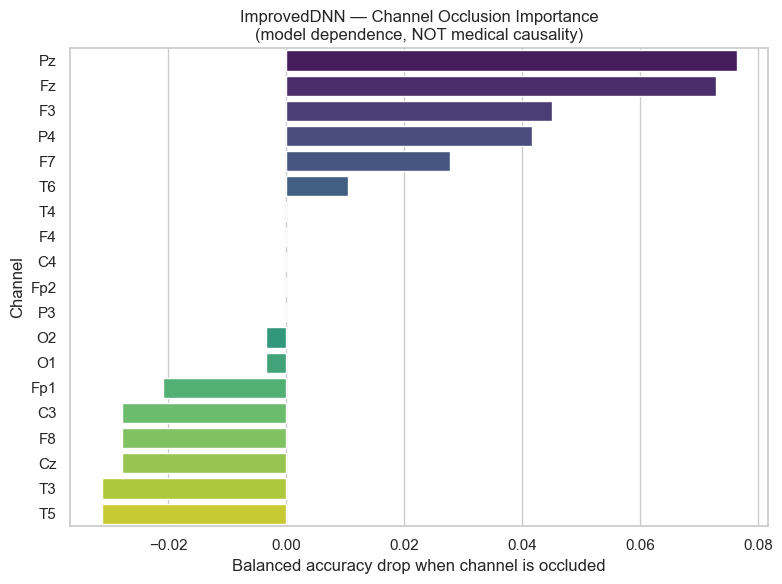

Full-channel baseline balanced accuracy: 0.8576


,channel,importance_drop
12,Pz,0.076389
6,Fz,0.072917
2,F3,0.045139
11,P4,0.041667
4,F7,0.027778
16,T6,0.010417
14,T4,0.000000
3,F4,0.000000
8,C4,0.000000
1,Fp2,0.000000


In [38]:
def channel_occlusion_importance(model, X_test, y_test_epoch, test_subject_ids, agg_cfg, is_eegnet=False):
    baseline_probs = get_epoch_probs(model, X_test)
    baseline_subj_probs = epoch_probs_to_subject_probs(baseline_probs, test_subject_ids, method=agg_cfg["method"])
    y_true_subj = subject_labels_from_ids(test_subject_ids, subject_id_to_label).loc[baseline_subj_probs.index]
    baseline_pred = (baseline_subj_probs.values >= agg_cfg["threshold"]).astype(int)
    baseline_bal_acc = balanced_accuracy_score(y_true_subj.values, baseline_pred)

    importances = {}
    for ci, ch in enumerate(CHANNELS):
        X_occluded = X_test.copy()
        if is_eegnet:
            X_occluded[:, ci, :, :] = 0.0
        else:
            X_occluded[:, :, ci] = 0.0

        occluded_probs = get_epoch_probs(model, X_occluded)
        occluded_subj_probs = epoch_probs_to_subject_probs(occluded_probs, test_subject_ids, method=agg_cfg["method"])
        occluded_pred = (occluded_subj_probs.loc[baseline_subj_probs.index].values >= agg_cfg["threshold"]).astype(int)
        occluded_bal_acc = balanced_accuracy_score(y_true_subj.values, occluded_pred)

        importances[ch] = baseline_bal_acc - occluded_bal_acc

    return importances, baseline_bal_acc


is_eegnet_best = (best_dl_name == "EEGNet")
best_dl_test_input = X_test_eegnet if is_eegnet_best else X_test_dnn
best_model_obj = eegnet_model if is_eegnet_best else improved_dnn_model
best_agg_cfg_final = eegnet_best_agg if is_eegnet_best else dnn_best_agg

channel_importance, baseline_bal_acc_full = channel_occlusion_importance(
    best_model_obj, best_dl_test_input, y_test_dnn, epoch_subject_ids["test"],
    best_agg_cfg_final, is_eegnet=is_eegnet_best)

importance_df = pd.DataFrame({"channel": list(channel_importance.keys()),
                               "importance_drop": list(channel_importance.values())})
importance_df = importance_df.sort_values("importance_drop", ascending=False)
importance_df.to_csv(RESULTS_DIR / "channel_occlusion_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance_drop", y="channel", hue="channel", legend=False,
            palette="viridis", ax=ax)
ax.set_xlabel("Balanced accuracy drop when channel is occluded")
ax.set_ylabel("Channel")
ax.set_title(f"{best_dl_name} — Channel Occlusion Importance\n"
             "(model dependence, NOT medical causality)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "13_channel_occlusion_importance.png")
plt.show()

print(f"Full-channel baseline balanced accuracy: {baseline_bal_acc_full:.4f}")
importance_df.head(10)


## 16. Final Model Comparison

Subject-level test-set metrics for all five models, side by side.


In [39]:
comparison_rows = []
for name in ["LogisticRegression", "SVM", "RandomForest"]:
    m = baseline_subj_metrics[name]
    comparison_rows.append({
        "Model": name, "Accuracy": m["accuracy"], "Balanced Accuracy": m["balanced_accuracy"],
        "Sensitivity": m["sensitivity_recall"], "Specificity": m["specificity"],
        "F1": m["f1"], "ROC-AUC": m["roc_auc"], "PR-AUC": m["pr_auc"], "MCC": m["mcc"],
    })

for name, m in [("EEGNet", eegnet_subj_metrics), ("ImprovedDNN", dnn_subj_metrics)]:
    comparison_rows.append({
        "Model": name, "Accuracy": m["accuracy"], "Balanced Accuracy": m["balanced_accuracy"],
        "Sensitivity": m["sensitivity_recall"], "Specificity": m["specificity"],
        "F1": m["f1"], "ROC-AUC": m["roc_auc"], "PR-AUC": m["pr_auc"], "MCC": m["mcc"],
    })

final_comparison_df = pd.DataFrame(comparison_rows).round(4)
final_comparison_df.to_csv(RESULTS_DIR / "final_comparison.csv", index=False)
final_comparison_df


,Model,Accuracy,Balanced Accuracy,Sensitivity,Specificity,F1,ROC-AUC,PR-AUC,MCC
0,LogisticRegression,0.7941,0.8021,0.9375,0.6667,0.8108,0.8819,0.8490,0.6205
1,SVM,0.8235,0.8160,0.6875,0.9444,0.7857,0.8299,0.8763,0.6600
2,RandomForest,0.8235,0.8264,0.8750,0.7778,0.8235,0.8958,0.9056,0.6528
3,EEGNet,0.8529,0.8611,1.0000,0.7222,0.8649,0.9410,0.9392,0.7418
4,ImprovedDNN,0.8529,0.8576,0.9375,0.7778,0.8571,0.9514,0.9459,0.7190


## 17. Saving All Outputs

Models, per-epoch predictions, per-subject predictions, full metrics table, the final comparison
table, and a JSON experiment config are all written to `models/` and `results/`. All plots were
already saved to `plots/` as PNGs as they were generated above.


In [41]:
# Models were already checkpointed to models/best_eegnet.keras and models/best_dnn.keras
# by ModelCheckpoint during training. Confirm they exist:
for p in [MODELS_DIR / "best_eegnet.keras", MODELS_DIR / "best_dnn.keras"]:
    print(p, "exists:", p.exists())

# --- Epoch-level predictions (deep learning models, test split) ---
epoch_pred_df = pd.DataFrame({
    "subject_id": epoch_subject_ids["test"],
    "true_label": y_test_dnn,
    "eegnet_prob": eegnet_test_epoch_probs,
    "dnn_prob": dnn_test_epoch_probs,
})
epoch_pred_df.to_csv(RESULTS_DIR / "epoch_predictions.csv", index=False)

# --- Subject-level predictions (all 5 models, test split) ---
subject_pred_rows = []
for sid in final_comparison_df["Model"].tolist():
    pass  # placeholder to keep structure explicit; actual assembly below

subj_pred_records = {}
for sid in feature_table.loc[feature_table.split == "test", "subject_id"]:
    subj_pred_records.setdefault(sid, {"subject_id": sid, "true_label": subject_id_to_label[sid]})

for name in ["LogisticRegression", "SVM", "RandomForest"]:
    test_subj_ids = feature_table.loc[feature_table.split == "test", "subject_id"].values
    probs = baseline_test_probs[name]
    preds = baseline_subj_preds[name]
    for sid, p, pr in zip(test_subj_ids, probs, preds):
        subj_pred_records[sid][f"{name}_prob"] = p
        subj_pred_records[sid][f"{name}_pred"] = int(pr)

for name, subj_probs, y_pred in [("EEGNet", eegnet_subj_probs, eegnet_y_pred_subj),
                                  ("ImprovedDNN", dnn_subj_probs, dnn_y_pred_subj)]:
    for sid, p, pr in zip(subj_probs.index, subj_probs.values, y_pred):
        subj_pred_records.setdefault(sid, {"subject_id": sid, "true_label": subject_id_to_label[sid]})
        subj_pred_records[sid][f"{name}_prob"] = p
        subj_pred_records[sid][f"{name}_pred"] = int(pr)

subject_pred_df = pd.DataFrame(list(subj_pred_records.values()))
subject_pred_df.to_csv(RESULTS_DIR / "subject_predictions.csv", index=False)

# --- Full metrics table (all models) ---
all_metrics_rows = []
for name, m in list(baseline_subj_metrics.items()) + [("EEGNet", eegnet_subj_metrics), ("ImprovedDNN", dnn_subj_metrics)]:
    row = {"model": name}
    row.update(m)
    all_metrics_rows.append(row)
all_metrics_df = pd.DataFrame(all_metrics_rows)
all_metrics_df.to_csv(RESULTS_DIR / "metrics.csv", index=False)

# --- Experiment configuration ---
experiment_config = {
    "seed": SEED,
    "fs": FS,
    "epoch_sec": EPOCH_SEC,
    "epoch_samples": EPOCH_SAMPLES,
    "band": BAND,
    "channels": CHANNELS,
    "bands": BANDS,
    "artifact_rejection": {
        "enabled": ARTIFACT_REJECTION_ENABLED,
        "std_threshold": ARTIFACT_STD_THRESHOLD,
        "abs_threshold": ARTIFACT_ABS_THRESHOLD,
    },
    "split": {"val_size": VAL_SIZE, "test_size": TEST_SIZE},
    "n_subjects": {
        "total": len(subject_index),
        "train": int((subject_index.split == "train").sum()),
        "val": int((subject_index.split == "val").sum()),
        "test": int((subject_index.split == "test").sum()),
    },
    "eegnet_aggregation": eegnet_best_agg,
    "dnn_aggregation": dnn_best_agg,
    "baseline_thresholds": baseline_thresholds,
    "best_dl_model": best_dl_name,
    "cv": {"run_cv": RUN_CV, "run_dl_cv": RUN_DL_CV, "cv_folds": CV_FOLDS},
}
with open(RESULTS_DIR / "experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=2, default=str)

print("All outputs saved under results/, plots/, and models/.")
print("\nFinal comparison table:")
print(final_comparison_df.to_string(index=False))


models/best_eegnet.keras exists: True
models/best_dnn.keras exists: True
All outputs saved under results/, plots/, and models/.

Final comparison table:
             Model  Accuracy  Balanced Accuracy  Sensitivity  Specificity     F1  ROC-AUC  PR-AUC    MCC
LogisticRegression    0.7941             0.8021       0.9375       0.6667 0.8108   0.8819  0.8490 0.6205
               SVM    0.8235             0.8160       0.6875       0.9444 0.7857   0.8299  0.8763 0.6600
      RandomForest    0.8235             0.8264       0.8750       0.7778 0.8235   0.8958  0.9056 0.6528
            EEGNet    0.8529             0.8611       1.0000       0.7222 0.8649   0.9410  0.9392 0.7418
       ImprovedDNN    0.8529             0.8576       0.9375       0.7778 0.8571   0.9514  0.9459 0.7190


## Summary

This notebook implemented a full, leakage-free pipeline for classifying Alzheimer's Disease vs.
Healthy Control subjects from eyes-closed resting-state EEG:

- Subjects were split **before** any signal was loaded, guaranteeing no epoch-level leakage.
- All normalization statistics were fit on training data only.
- Three classical baselines (Logistic Regression, SVM, Random Forest) and two compact deep
  networks (EEGNet-inspired CNN, Improved DNN with residual + attention blocks) were trained and
  compared using identical, frozen evaluation protocols.
- Subject-level aggregation method and decision threshold were selected on validation data only
  and frozen before touching the test set.
- Results include bootstrap confidence intervals, subject-level 5-fold cross-validation, and
  channel occlusion interpretability.

**Reminder:** this is a research pipeline on a modestly sized dataset (~232 subjects). Results
should be interpreted as a methodological demonstration, not as clinically validated diagnostic
performance.
